# **12주차 과제 — 답지 (Q1~Q4)**

- 본 답지는 채점 참고용 코드 예시입니다.
- 데이터 경로: `./data/data_thelook_ecommerce/`
- Q3~Q4: BigQuery service account key (`./service_account.json`) 필요. 키가 없으면 코드만 확인.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

for cand in ['/home/pc/.local/share/fonts/NanumGothic-Regular.ttf',
             '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
             '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc']:
    if os.path.exists(cand):
        try:
            fm.fontManager.addfont(cand)
        except Exception:
            pass
        plt.rcParams['font.family'] = fm.FontProperties(fname=cand).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

## **Q1. 클래스 설계 — 네이버 뉴스 정보 크롤링**

In [2]:
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import quote


class news_collector:
    def __init__(self):
        self.result_df = None
        self.press_top5 = None
        self._headers = {
            'User-Agent': (
                'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                'AppleWebKit/537.36 (KHTML, like Gecko) '
                'Chrome/124.0.0.0 Safari/537.36'
            )
        }

    def _fetch_one(self, keyword):
        url = f'https://search.naver.com/search.naver?where=news&query={quote(keyword)}'
        res = requests.get(url, headers=self._headers, timeout=10)
        soup = BeautifulSoup(res.text, 'html.parser')

        rows = []
        for item in soup.select('div.fds-news-item-list-tab > div'):
            title_span = item.select_one('span.sds-comps-text-type-headline1')
            if not title_span:
                continue
            title_a = title_span.find_parent('a')
            press_img = item.select_one('img[alt*="프로필 이미지"]')
            press = press_img['alt'].replace('의 프로필 이미지', '').strip() if press_img else ''
            summary_span = item.select_one('span.sds-comps-text-type-body1')
            rows.append({
                '검색어': keyword,
                '제목': title_span.get_text(strip=True),
                '링크': title_a['href'] if title_a else '',
                '언론사': press,
                '요약': summary_span.get_text(strip=True) if summary_span else ''
            })
        return rows

    def naver_news_search(self, search_keyword_list):
        all_rows = []
        for kw in search_keyword_list:
            all_rows.extend(self._fetch_one(kw))
            time.sleep(0.5)

        df = pd.DataFrame(all_rows)
        n_total = len(df)
        df_dedup = df.drop_duplicates(subset=['제목', '언론사']).reset_index(drop=True)
        n_dedup = len(df_dedup)
        n_dup = n_total - n_dedup

        print(f'수집 데이터 갯수 : {n_total}')
        print(f'중복 데이터 갯수 : {n_dup}')
        print(f'중복 제거 데이터 갯수 : {n_dedup}')

        self.result_df = df_dedup[['검색어', '제목', '언론사', '요약']].copy()
        self.press_top5 = self.result_df['언론사'].value_counts().head(5)

    def press_search(self, press_col, keyword_col, press_list):
        df = self.result_df
        for press in press_list:
            sub = df[df[press_col] == press]
            if len(sub) == 0:
                print(f'[{press}] 데이터 없음')
                continue
            ratio = sub[keyword_col].value_counts(normalize=True) * 100

            fig, ax = plt.subplots(figsize=(5, 5))
            ax.pie(
                ratio.values,
                labels=ratio.index,
                autopct='%.1f%%',
                wedgeprops=dict(width=0.4)
            )
            ax.set_title(f'{press} — 검색어 비율')
            plt.show()

In [3]:
news_class = news_collector()
news_class.naver_news_search(search_keyword_list=['게임', '영화', '음악', 'AI', '위메이드'])

수집 데이터 갯수 : 50
중복 데이터 갯수 : 0
중복 제거 데이터 갯수 : 50


In [4]:
print('='*30, 'news_class.result_df.shape 확인결과', '='*30)
print(news_class.result_df.shape)

============================== news_class.result_df.shape 확인결과 ==============================
(50, 4)


In [5]:
print('='*30, 'news_class.result_df 확인결과', '='*30)
display(news_class.result_df)

============================== news_class.result_df 확인결과 ==============================


,검색어,제목,언론사,요약
0,게임,유통가 5월 대목 잡기…보드게임부터 반값 전복까지 ‘가족 지갑’ 열린...,세계일보,롯데백화점 잠실 롯데월드몰은 오는 26일까지 ‘보드게임대축제’ 팝업을 연다. 할리갈...
1,게임,`방시혁 구속영장` 검·경 핑퐁게임…신병 확보 `제동`,이데일리,자본시장법 위반 혐의를 받는 방시혁 하이브 이사회 의장에 대해 경찰이 구속영장을 다...
2,게임,"엔씨, 3년 연속 DJBIC 아시아 퍼시픽 지수 편입..'국내게임사 중 유일'",게임동아,"여기에 편입되면 ESG 경쟁력에 특화되어 있다는 평가를 받게되며, 엔씨는 국내게임기..."
3,게임,[게임위드인] 바다이야기 시절 멈춘게임경품 규제 해결은,연합뉴스,유저 기념품 지급·유통업체 미니게임도입 발목 잡아 아케이드게임·웹보드·P2E 등 쟁...
4,게임,"[주말엔게임]""게임개발자 11억에 모셔요""…넷플릭스는 왜게임에 진심...",아시아경제,게임부문 머신러닝 연구원 채용 공고다. 넷플릭스가 요구하는 핵심 업무는게임용 거대언...
5,게임,"‘머니게임’ 빠진 韓, 울리는 과열 경고음",문화일보,반도체 수출 호조를 앞세운 대외 지표 개선에 힘입어 국내 증시 시가총액이 세계 7위...
6,게임,"박홍근 기획예산처 장관, '아시안게임준비' 국가대표 선수단 격려",뉴스1,박홍근 기획예산처 장관이 2026 아이치·나고야 아시안게임을 준비 중인 국가대표 선...
7,게임,"엔씨 ESG 3관왕·넷마블 성장세 유지…게임협회 ""소통이 흥행"" [이주의 ...",조세일보,"게임업계가 대외 평가, 재무 성과, 이용자 소통이라는 세 축에서 동시에 주목할 만한..."
8,게임,"[위클리오늘] 온라인게임_넷마블, 컴투스(5.8)",위클리오늘,언리얼 엔진5 적용을 중심으로게임전반을 새롭게 개편하며 장기 서비스 경쟁력 강화에 ...
9,게임,‘핵심 광물’ 잡아라…아프리카로 번진 미-중 21세기 그레이트게임[...,한겨레,아프리카의 자원을 둘러싼 미-중 경쟁이 본격화하자 핵심 자원을 둘러싼 새로운 ‘그레...


In [6]:
print('='*30, 'news_class.press_top5 확인결과', '='*30)
display(news_class.press_top5)

============================== news_class.press_top5 확인결과 ==============================


언론사
연합뉴스    7
뉴시스     6
매일경제    3
세계일보    2
이데일리    2
Name: count, dtype: int64

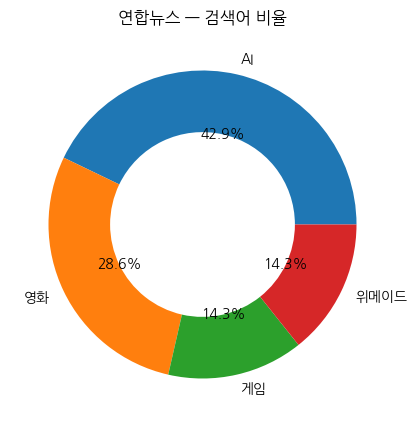

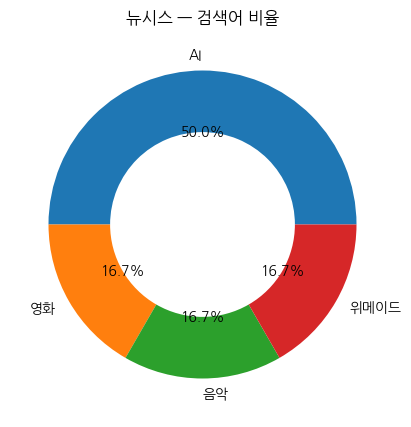

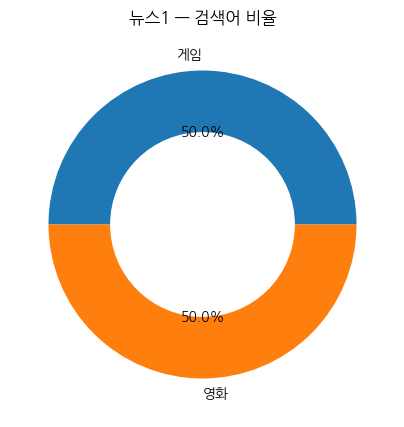

In [7]:
news_class.press_search(
    press_col='언론사',
    keyword_col='검색어',
    press_list=['연합뉴스', '뉴시스', '뉴스1']
)

## **Q2. 데이터 전처리 — Pandas**

In [8]:
import pandas as pd

df_orders = pd.read_csv('./data/data_thelook_ecommerce/orders.csv')
df_users = pd.read_csv('./data/data_thelook_ecommerce/users.csv')

print(df_orders.shape)
print(df_orders.columns)
print(df_users.shape)
print(df_users.columns)

(125210, 9)
Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item'],
      dtype='str')
(100000, 16)
Index(['id', 'first_name', 'last_name', 'email', 'age', 'gender', 'state',
       'street_address', 'postal_code', 'city', 'country', 'latitude',
       'longitude', 'traffic_source', 'created_at', 'user_geom'],
      dtype='str')


### 전처리 1 — 국가별 3회 이상 주문자 비율

In [ ]:
# 전처리 1: 국가별 3회 이상 주문자 비율 (점유율 방식)
# - 모집단: 'Shipped' 상태 주문을 3회 이상 한 사용자 568명 전체
# - user_count: 국가별 3회+ 주문자 수
# - user_ratio: user_count / 전체 568 × 100 (소수 1자리)

shipped = df_orders[df_orders['status'] == 'Shipped']
merged = shipped.merge(
    df_users[['id', 'country']],
    left_on='user_id', right_on='id', how='inner'
)

# 사용자별 주문 횟수 집계
user_order_cnt = (
    merged.groupby(['user_id', 'country']).size().reset_index(name='order_count')
)

# 3회 이상 주문자만 필터
user_3plus = user_order_cnt[user_order_cnt['order_count'] >= 3]

# 국가별 3회+ 주문자 수 + 점유율
user_summary = (
    user_3plus.groupby('country').size().reset_index(name='user_count')
    .sort_values('user_count', ascending=False)
    .reset_index(drop=True)
)
user_summary['user_ratio'] = (
    user_summary['user_count'] / user_summary['user_count'].sum() * 100
).round(1)
user_summary

### 전처리 2 — 국가별 주문 횟수 비율

In [10]:
order_summary = (
    merged.groupby('country').size().reset_index(name='order_count')
)
order_summary['order_ratio'] = (
    order_summary['order_count'] / order_summary['order_count'].sum() * 100
)
order_summary = order_summary.sort_values('order_count', ascending=False).reset_index(drop=True)
order_summary

,country,order_count,order_ratio
0,China,12875,33.954850
1,United States,8362,22.052851
2,Brasil,5581,14.718603
3,South Korea,1958,5.163774
4,United Kingdom,1823,4.807743
5,France,1753,4.623134
6,Germany,1590,4.193259
7,Spain,1561,4.116778
8,Japan,974,2.568701
9,Australia,862,2.273327


### 데이터 결합

In [11]:
country_summary = user_summary.merge(order_summary, on='country', how='inner')
country_summary

,country,user_count,user_ratio,order_count,order_ratio
0,Poland,67,4.477612,81,0.213619
1,United Kingdom,1562,1.920615,1823,4.807743
2,Japan,840,1.904762,974,2.568701
3,South Korea,1680,1.904762,1958,5.163774
4,Brasil,4774,1.843318,5581,14.718603
5,China,11066,1.789264,12875,33.954850
6,United States,7224,1.758029,8362,22.052851
7,Australia,739,1.623816,862,2.273327
8,Spain,1334,1.499250,1561,4.116778
9,Belgium,424,1.415094,490,1.292262


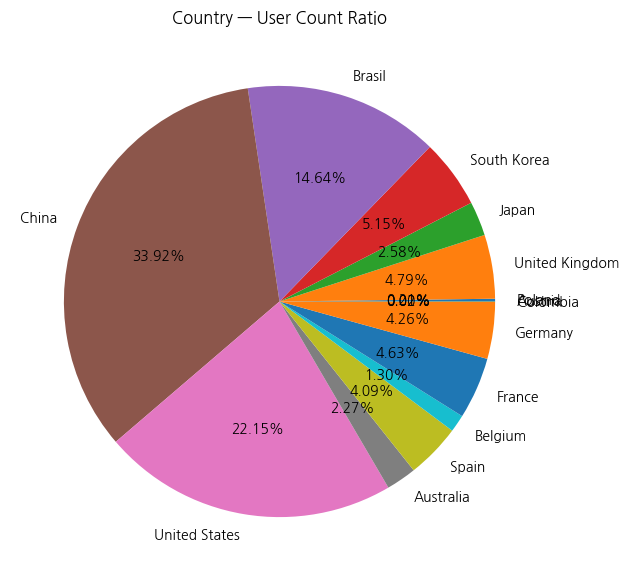

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    country_summary['user_count'],
    labels=country_summary['country'],
    autopct='%.2f%%'
)
ax.set_title('Country — User Count Ratio')
plt.show()

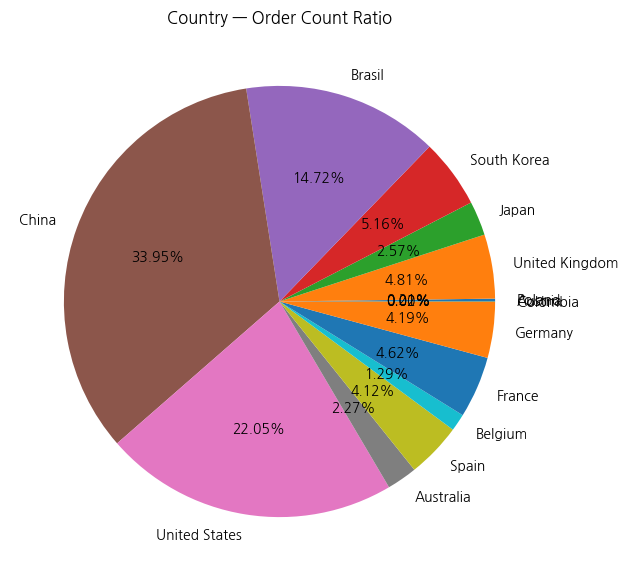

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    country_summary['order_count'],
    labels=country_summary['country'],
    autopct='%.2f%%'
)
ax.set_title('Country — Order Count Ratio')
plt.show()

## **Q3. BigQuery 전처리 1**

- `bigquery-public-data.thelook_ecommerce` 활용
- 단일 쿼리로 Q2와 동일 결과 재현
- 실행: `./service_account.json` (서비스 계정 키) 필요

In [14]:
import os

KEY_PATH = './service_account.json'
_bq_ready = False
client = None

if os.path.exists(KEY_PATH):
    try:
        from google.oauth2 import service_account
        from google.cloud import bigquery
        credentials = service_account.Credentials.from_service_account_file(KEY_PATH)
        client = bigquery.Client(credentials=credentials, project=credentials.project_id)
        _bq_ready = True
        print('BigQuery 클라이언트 준비 완료')
    except Exception as e:
        print(f'BigQuery 초기화 실패: {e}')
else:
    print(f'⚠️ {KEY_PATH} 가 없어 Q3~Q4는 코드만 확인합니다.')
    print('   본인 BigQuery 서비스 계정 키 파일을 위 경로에 두고 재실행하세요.')

⚠️ ./service_account.json 가 없어 Q3~Q4는 코드만 확인합니다.
   본인 BigQuery 서비스 계정 키 파일을 위 경로에 두고 재실행하세요.


### Query 1 — 국가별 3회 이상 주문자 비율

In [ ]:
# Query 1: 국가별 3회 이상 주문자 비율 (점유율 방식)
# 단일 BigQuery 쿼리로 Q2 전처리 1과 동일 결과 재현

query_1 = """
WITH shipped AS (
  SELECT o.user_id, u.country
  FROM `bigquery-public-data.thelook_ecommerce.orders` o
  JOIN `bigquery-public-data.thelook_ecommerce.users` u
    ON o.user_id = u.id
  WHERE o.status = 'Shipped'
),
user_3plus AS (
  SELECT country, user_id
  FROM shipped
  GROUP BY country, user_id
  HAVING COUNT(*) >= 3
),
country_stats AS (
  SELECT country, COUNT(user_id) AS user_count
  FROM user_3plus
  GROUP BY country
)
SELECT
  country,
  user_count,
  ROUND(user_count / SUM(user_count) OVER() * 100, 1) AS user_ratio
FROM country_stats
ORDER BY user_count DESC
"""

if _bq_ready:
    df_q3_1 = client.query(query_1).to_dataframe()
    display(df_q3_1)
else:
    print('--- 쿼리만 출력 ---')
    print(query_1)

### Query 2 — 국가별 주문 횟수 비율

In [16]:
query_2 = """
WITH shipped AS (
  SELECT o.order_id, u.country
  FROM `bigquery-public-data.thelook_ecommerce.orders` o
  JOIN `bigquery-public-data.thelook_ecommerce.users` u
    ON o.user_id = u.id
  WHERE o.status = 'Shipped'
)
SELECT
  country,
  COUNT(*) AS order_count,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER () * 100, 6) AS order_ratio
FROM shipped
GROUP BY country
ORDER BY order_count DESC
"""

if _bq_ready:
    df_q3_2 = client.query(query_2).to_dataframe()
    display(df_q3_2)
else:
    print('--- 쿼리만 출력 ---')
    print(query_2)

--- 쿼리만 출력 ---

WITH shipped AS (
  SELECT o.order_id, u.country
  FROM `bigquery-public-data.thelook_ecommerce.orders` o
  JOIN `bigquery-public-data.thelook_ecommerce.users` u
    ON o.user_id = u.id
  WHERE o.status = 'Shipped'
)
SELECT
  country,
  COUNT(*) AS order_count,
  ROUND(COUNT(*) / SUM(COUNT(*)) OVER () * 100, 6) AS order_ratio
FROM shipped
GROUP BY country
ORDER BY order_count DESC



## **Q4. BigQuery 전처리 2**

- 참고이미지(`Q4.png`) 결과를 단일 쿼리로 재현
- ⚠️ 실제 채점 시 참고이미지의 컬럼·정렬·필터를 그대로 반영해야 함

In [ ]:
# Q4: 단일 BigQuery 쿼리로 Q4.png 결과 재현
# 컬럼: country, user_count, user_ratio, order_count, order_ratio
# user_count = 국가별 3회+ 주문자 수, user_ratio = 점유율 (소수 1자리)
# order_count = 국가별 Shipped 주문 수, order_ratio = 점유율
# 정렬: user_count DESC

query_q4 = """
WITH shipped AS (
  SELECT o.user_id, o.order_id, u.country
  FROM `bigquery-public-data.thelook_ecommerce.orders` o
  JOIN `bigquery-public-data.thelook_ecommerce.users` u
    ON o.user_id = u.id
  WHERE o.status = 'Shipped'
),
user_3plus AS (
  SELECT country, user_id
  FROM shipped
  GROUP BY country, user_id
  HAVING COUNT(order_id) >= 3
),
user_summary AS (
  SELECT country, COUNT(user_id) AS user_count
  FROM user_3plus
  GROUP BY country
),
order_summary AS (
  SELECT country, COUNT(order_id) AS order_count
  FROM shipped
  GROUP BY country
)
SELECT
  u.country,
  u.user_count,
  ROUND(u.user_count / SUM(u.user_count) OVER() * 100, 1) AS user_ratio,
  o.order_count,
  ROUND(o.order_count / SUM(o.order_count) OVER() * 100, 1) AS order_ratio
FROM user_summary u
JOIN order_summary o ON u.country = o.country
ORDER BY u.user_count DESC
"""

if _bq_ready:
    df_q4 = client.query(query_q4).to_dataframe()
    display(df_q4)
else:
    print('--- 쿼리만 출력 ---')
    print(query_q4)